In [1]:
# -*- coding: utf-8 -*-
"""
LSTM Housing Forecast - Corrected Notebook

This notebook implements LSTM-based forecasting for house price indices 
with Bayesian hyperparameter tuning, using the corrected utility functions.
"""

# In[1]: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from sklearn.preprocessing import StandardScaler # Keep for potential direct use if needed
import time
import warnings
import os # Added for managing directories if needed

# Import our custom LSTM utilities (ensure dc_housing_lstm_utils.py is in the same directory or path)
import dc_housing_lstm_utils as lstm_utils

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
warnings.filterwarnings('ignore')
print("Libraries loaded.")

Libraries loaded.


In [2]:
# In[2]: Configuration Parameters

# --- File Paths & Column Names ---
file_path = 'Preselect.csv'
date_col = 'Date' # Ensure this matches the CSV header if loading again
target_pct_change_col = 'House_Index_pct_change'
target_level_col = 'House_Index'

# --- Data Splitting & Filtering ---
# Dates for walk-forward validation splitting
train_end_date_str = '2015-12-31'
test_start_date_str = '2016-01-01'
# Final date of historical data to consider for both WFV and final forecast training
final_historical_date_str = '2024-10-01'

# --- LSTM Parameters ---
n_timesteps = 4    # Lookback window
n_outputs = 8      # Number of steps to predict ahead (used for WFV and final forecast)

# --- Training & Tuning Parameters ---
# Walk-Forward Validation Tuning/Training
wfv_tuner_max_trials = 8   # Trials per WFV step (as original)
wfv_tuner_epochs = 15      # Tuner epochs per WFV step (as original)
wfv_final_model_epochs = 50 # Final model epochs per WFV step (as original)
wfv_lstm_batch_size = 16    # Batch size per WFV step (as original)
wfv_lstm_patience = 10      # Early stopping patience per WFV step (as original)

# Final Forecast Tuning/Training (using parameters from the second original script)
final_tuner_max_trials = 15 # Trials for final tuning (as second script)
final_tuner_epochs = 15     # Tuner epochs for final tuning (as second script)
final_model_epochs = 50     # Final model epochs (as second script)
final_lstm_batch_size = 16  # Final model batch size (as second script)
final_lstm_patience = 10    # Final model early stopping patience (as second script)

# --- Other Settings ---
tune_dropout = True # Consistent with original scripts
horizons_to_plot_wfv = [1, 4, 8] # Which horizons to plot for WFV results

print("Configuration set.")
print(f"LSTM Timesteps: {n_timesteps}, Predict Ahead: {n_outputs}")

Configuration set.
LSTM Timesteps: 4, Predict Ahead: 8


In [3]:
# In[3]: Data Loading and Preparation
print("Loading and preparing data...")

# 1. Load data
try:
    # Use read_csv correctly with date parsing and index setting
    df = pd.read_csv(file_path, parse_dates=[date_col], index_col=date_col)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # Remove unnamed columns
    df.sort_index(inplace=True)
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    raise
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# 2. Define feature and target columns
feature_cols = [col for col in df.columns if col not in [target_level_col, target_pct_change_col]]
if not feature_cols:
     raise ValueError("No feature columns identified.")
required_targets = [target_pct_change_col, target_level_col]
missing_targets = [col for col in required_targets if col not in df.columns]
if missing_targets:
     raise ValueError(f"Missing required target columns: {missing_targets}")

# 3. Create FULL DataFrames (before filtering/processing specific to WFV/Final)
# These will be passed to the utility functions which handle internal filtering/processing
X_full_df = df[feature_cols].copy()
y_pct_change_full_df = df[[target_pct_change_col]].copy()
y_level_full_df = df[[target_level_col]].copy()
print(f"\nFull DataFrames created:")
print(f"  Features (X_full_df): {X_full_df.shape}")
print(f"  Pct Change Target (y_pct_change_full_df): {y_pct_change_full_df.shape}")
print(f"  Level Target (y_level_full_df): {y_level_full_df.shape}")

# NOTE: The filtering, NaN handling, and train/test splitting specific to WFV 
#       will now happen *inside* the run_lstm_walk_forward utility function.
#       Similarly, filtering/NaN handling for the final forecast happens 
#       inside the final_lstm_forecast utility function.

Loading and preparing data...
Data loaded successfully. Shape: (131, 85)
Date range: 1992-04-01 00:00:00 to 2024-10-01 00:00:00

Full DataFrames created:
  Features (X_full_df): (131, 83)
  Pct Change Target (y_pct_change_full_df): (131, 1)
  Level Target (y_level_full_df): (131, 1)


In [4]:
# In[4]: LSTM Walk-Forward Validation
print("\n--- Starting LSTM Walk-Forward Validation ---")
# Ensure the tuner directory is specified and potentially cleaned by the util function
wfv_tuner_dir = 'lstm_bo_tuner_wf_notebook_dir' # Specific dir for notebook WFV run

start_wfv_time = time.time()

# *** CORRECTED CALL V3: Pass the FULL dataframes and date strings ***
# The utility function run_lstm_walk_forward expects the full dataframes and performs
# filtering, splitting, NaN handling, scaling, etc., internally.
lstm_results_df, plot_dfs_wfv = lstm_utils.run_lstm_walk_forward(
    X_all_df=X_full_df,  # Pass the full features DataFrame created in In[3]
    y_pct_change_all_df=y_pct_change_full_df, # Pass the full pct change target DataFrame
    y_level_all_df=y_level_full_df, # Pass the full level target DataFrame
    # Date strings for splitting inside the function:
    train_end_date_str=train_end_date_str,
    test_start_date_str=test_start_date_str,
    final_historical_date_str=final_historical_date_str, # Filter data up to this date inside function
    # Other parameters:
    n_timesteps=n_timesteps,
    n_outputs=n_outputs,
    target_level_col=target_level_col, # Name of the level column is still needed
    tune_dropout=tune_dropout,
    tuner_max_trials=wfv_tuner_max_trials,
    tuner_epochs=wfv_tuner_epochs,
    final_model_epochs=wfv_final_model_epochs,
    lstm_batch_size=wfv_lstm_batch_size,
    lstm_patience=wfv_lstm_patience,
    tuner_dir=wfv_tuner_dir
)

end_wfv_time = time.time()
print(f"\n--- LSTM Walk-Forward Validation Finished ({end_wfv_time - start_wfv_time:.2f} seconds) ---")

print("\n--- LSTM Model WFV Results by Forecast Horizon ---")
# Display results, handling potential NaNs nicely
print(lstm_results_df.to_string(float_format="%.3f"))

# Calculate and print average metrics across valid horizons
valid_metrics_wfv = lstm_results_df.dropna()
if not valid_metrics_wfv.empty:
     avg_metrics_wfv = valid_metrics_wfv.drop(columns='Forecast Horizon (Steps)').mean()
     print(f"\n--- Average LSTM WFV Performance Across Valid Horizons ---")
     print(f"  Avg MSE: {avg_metrics_wfv.get('MSE', np.nan):.3f}")
     print(f"  Avg RMSE: {avg_metrics_wfv.get('RMSE', np.nan):.3f}")
     print(f"  Avg MAE: {avg_metrics_wfv.get('MAE', np.nan):.3f}")
     print(f"  Avg MAPE (%): {avg_metrics_wfv.get('MAPE', np.nan):.3f}")
     # Ensure column name matches the one returned by the util function (e.g., 'DA' or 'Dir_Acc')
     da_col_name = 'DA' if 'DA' in avg_metrics_wfv else 'Dir_Acc' # Adapt if needed
     print(f"  Avg DA (%): {avg_metrics_wfv.get(da_col_name, np.nan):.3f}") 
else:
     print("\nNo valid horizons found to calculate average WFV performance.")


--- Starting LSTM Walk-Forward Validation ---
--- Starting Utility: run_lstm_walk_forward ---
Dropped 0 rows containing NaNs.
Initial training data shape: X=(95, 83), y_pct=(95, 1)
Test data shape: X=(36, 83), y_pct=(36, 1)
Scaling features and target (fitting only on initial training data)...
Scaling complete.
Creating sequences for the entire dataset (n_timesteps=4, n_outputs=8)...
Total sequences created: 120
Sequence Train shapes: X=(91, 4, 83), y=(91, 8)
Sequence Test shapes: X=(29, 4, 83), y=(29, 8)
Number of test forecast origins: 29

Starting walk-forward validation (LSTM with Bayesian Optimization Tuning)...
Using Tuner Directory: lstm_bo_tuner_wf_notebook_dir
Cleaning previous tuner directory: lstm_bo_tuner_wf_notebook_dir
Inferred frequency: QS-OCT
Using offset: <QuarterBegin: startingMonth=10>

Processing Origin 1/29 (Input Ends: 2015-10-01)...
   Tuning hyperparameters (max_trials=8)...

   Best HPs found: Units=108, LR=1.0e-05, Dropout=0.3
   Training final model for ste


--- Plotting LSTM Walk-Forward Results ---
Walk-forward plot saved as 'lstm_multioutput_wfv_comparison.png'


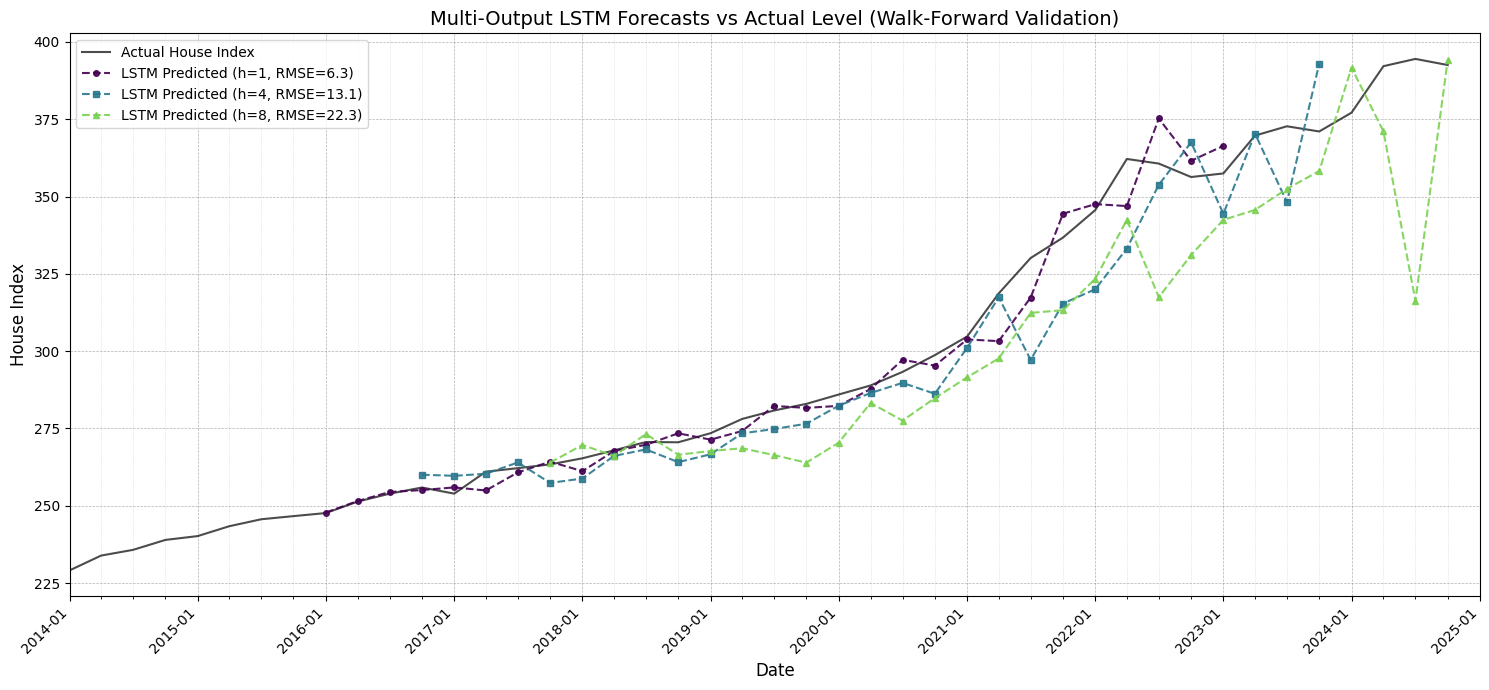

In [5]:
# In[5]: Visualize Walk-Forward Results
print("\n--- Plotting LSTM Walk-Forward Results ---")

# Check if plot_dfs_wfv contains data
if not plot_dfs_wfv or all(df.empty for df in plot_dfs_wfv.values()):
    print("No data available for plotting walk-forward results.")
else:
    plt.figure(figsize=(15, 7)) # Single plot for comparison

    # Determine overall plot range from the returned plot dataframes
    min_plot_date = min((df.index.min() for h, df in plot_dfs_wfv.items() if h in horizons_to_plot_wfv and not df.empty), default=pd.to_datetime(test_start_date_str))
    max_plot_date = max((df.index.max() for h, df in plot_dfs_wfv.items() if h in horizons_to_plot_wfv and not df.empty), default=pd.to_datetime(final_historical_date_str))

    # Plot historical data in the relevant range for context
    # Use y_level_full_df which contains the full original level data
    plot_start_hist_date = min_plot_date - pd.DateOffset(years=2) # Show some history before predictions start
    # Filter the full level data for plotting background
    actual_data_subset = y_level_full_df[(y_level_full_df.index >= plot_start_hist_date) & (y_level_full_df.index <= max_plot_date)]
    if not actual_data_subset.empty:
         plt.plot(actual_data_subset.index, actual_data_subset[target_level_col], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)

    # Define colors and markers for different horizons
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(horizons_to_plot_wfv)))
    markers = ['o', 's', '^', 'd', 'x', '+'] # Add more if plotting more horizons

    # Plot predictions for selected horizons
    for i, h in enumerate(horizons_to_plot_wfv):
        if h in plot_dfs_wfv and not plot_dfs_wfv[h].empty:
            results_df = plot_dfs_wfv[h]
            # Safely get RMSE, handle if horizon missing in results
            rmse_h_series = lstm_results_df.loc[lstm_results_df['Forecast Horizon (Steps)'] == h, 'RMSE']
            rmse_h = rmse_h_series.iloc[0] if not rmse_h_series.empty else np.nan
            label = f'LSTM Predicted (h={h}, RMSE={rmse_h:.1f})'
            plt.plot(results_df.index, results_df['Predicted_Level'],
                     label=label, color=colors[i % len(colors)],
                     marker=markers[i % len(markers)], linestyle='--', markersize=4, alpha=0.9)
        else:
            print(f"No plot data found for horizon h={h}.")

    # Formatting the plot
    plt.title('Multi-Output LSTM Forecasts vs Actual Level (Walk-Forward Validation)', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('House Index', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='lightgrey')

    # Set reasonable x-axis limits
    plt.xlim(plot_start_hist_date, max_plot_date + pd.DateOffset(months=3)) # Add padding

    # Format date axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) # Major ticks every year
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3)) # Minor ticks every 3 months
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    try:
        save_fname_wfv = 'lstm_multioutput_wfv_comparison.png'
        plt.savefig(save_fname_wfv, dpi=300, bbox_inches='tight')
        print(f"Walk-forward plot saved as '{save_fname_wfv}'")
    except Exception as e:
        print(f"Error saving walk-forward plot: {e}")
    plt.show()

In [6]:
# In[6]: Generate Final Forecast
print("\n--- Generating Final LSTM Forecast ---")
# Ensure the tuner directory is specified
final_tuner_dir = 'lstm_bo_tuner_final_notebook_dir' # Specific dir for notebook final run

start_final_time = time.time()

# Call the corrected utility function
# It uses data up to final_historical_date_str for tuning and training
# It then predicts n_outputs steps ahead from that point
# Pass the FULL dataframes. The function handles filtering/NaNs internally.
forecast_df, final_model, best_hps_final, final_scaler_X, final_scaler_y = lstm_utils.final_lstm_forecast(
    X_all_df=X_full_df, # Pass the full features DataFrame
    y_pct_change_all_df=y_pct_change_full_df, # Pass the full pct change target DataFrame
    y_level_all_df=y_level_full_df, # Pass the full level target DataFrame
    final_train_end_date_str=final_historical_date_str, # Train on data UP TO this date (handled inside function)
    num_forecast_steps=n_outputs, # Predict this many steps ahead
    target_level_col=target_level_col,
    n_timesteps=n_timesteps,
    tune_dropout=tune_dropout,
    tuner_max_trials=final_tuner_max_trials,
    tuner_epochs=final_tuner_epochs,
    final_model_epochs=final_model_epochs,
    lstm_batch_size=final_lstm_batch_size,
    lstm_patience=final_lstm_patience,
    tuner_dir=final_tuner_dir
)

end_final_time = time.time()
print(f"\n--- Final LSTM Forecast Generation Finished ({end_final_time - start_final_time:.2f} seconds) ---")

print("\n--- Final LSTM Forecast ---")
if forecast_df.empty:
    print("No forecast generated.")
else:
    print(forecast_df.round(4))

# Optionally print final best hyperparameters
if best_hps_final:
     print("\n--- Final Model Best Hyperparameters ---")
     print(f"  Units: {best_hps_final.get('units')}")
     # Safely format learning rate
     lr_final = best_hps_final.get('learning_rate')
     lr_final_str = f"{lr_final:.1e}" if lr_final is not None else 'NA'
     print(f"  Learning Rate: {lr_final_str}")
     if tune_dropout and best_hps_final.get('dropout') is not None:
         print(f"  Dropout: {best_hps_final.get('dropout'):.1f}")

Trial 15 Complete [00h 00m 07s]
val_loss: 0.7122290134429932

Best val_loss So Far: 0.6927775740623474
Total elapsed time: 00h 01m 05s

Final Tuning Complete (65.40s).
   Best HPs found: Units=64, LR=5.0e-05, Dropout=0.3

Training final model with best HPs (max_epochs=50)...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3715
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3414  
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3432  
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2992  
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3183 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3058 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2986  
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2361  
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2749  
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2472  
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2049  
Epoch 12/50


--- Plotting Final LSTM Forecast ---
Final forecast plot saved as 'lstm_final_forecast_2024-10-01.png'


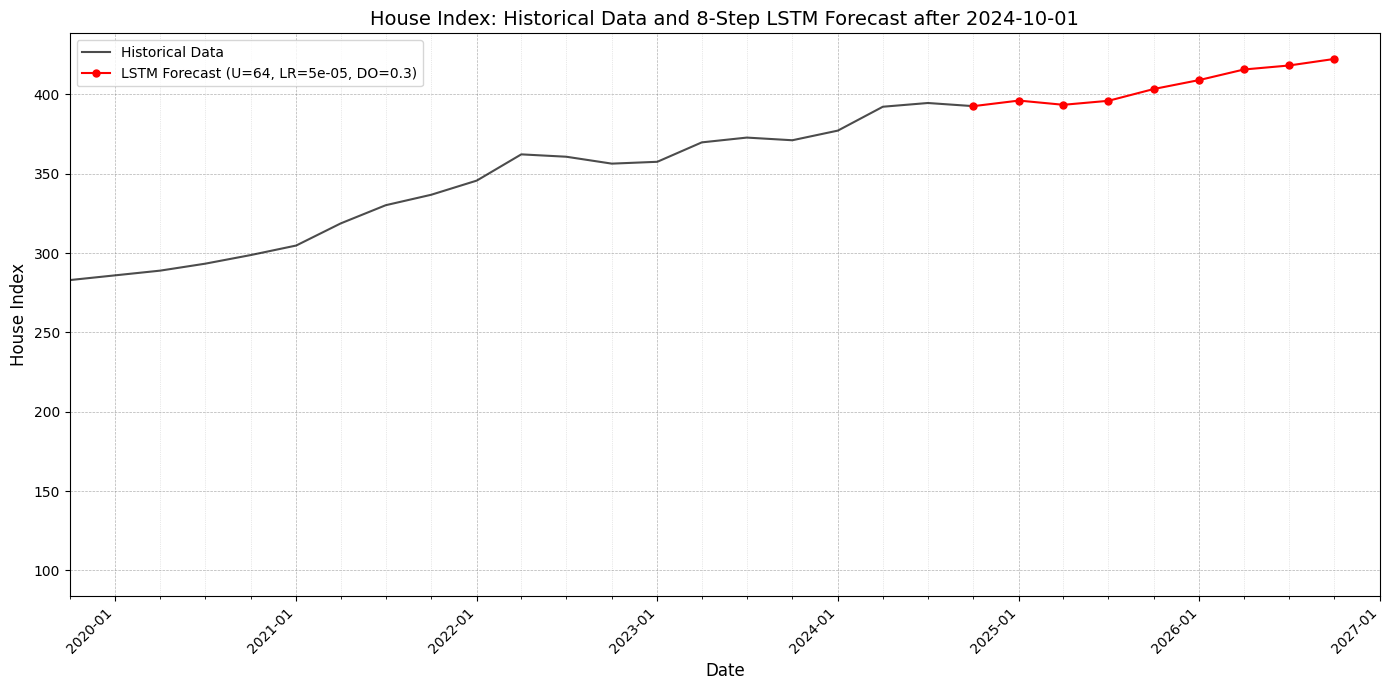


LSTM modeling and forecasting complete!


In [7]:
# In[7]: Visualize Final Forecast
print("\n--- Plotting Final LSTM Forecast ---")

if forecast_df.empty:
    print("Cannot plot final forecast: No forecast data generated.")
else:
    plt.figure(figsize=(14, 7))

    # Plot historical data (using y_level_full_df for full original history context)
    plt.plot(y_level_full_df.index, y_level_full_df[target_level_col].values, 'k-', label='Historical Data', linewidth=1.5, alpha=0.7)

    # Get last historical point from the data *actually used* for the final forecast training
    # which is y_level_full_df filtered up to final_historical_date_str and NaN dropped.
    # Re-filter y_level_full_df to get the correct last point for plotting connection.
    final_hist_date_dt_plot = pd.to_datetime(final_historical_date_str)
    # Combine relevant columns and dropna to mimic data used in final_lstm_forecast
    plot_connect_df = pd.concat([X_full_df, y_pct_change_full_df, y_level_full_df], axis=1)
    plot_connect_df_filtered = plot_connect_df[plot_connect_df.index <= final_hist_date_dt_plot].copy()
    plot_connect_df_processed = plot_connect_df_filtered.dropna()
    
    if not plot_connect_df_processed.empty:
        last_date = plot_connect_df_processed.index[-1]
        last_value = plot_connect_df_processed[target_level_col].iloc[-1]

        # Create a Series for the last known point
        last_point_series = pd.Series([last_value], index=[last_date])
        # Concatenate with the forecast Series
        forecast_series_to_plot = pd.concat([last_point_series, forecast_df['LSTM_Forecast']])

        # Plot combined line (last historical point + forecast)
        forecast_label = 'LSTM Forecast'
        if best_hps_final: # Add HP details to label if available
            units = best_hps_final.get('units')
            lr = best_hps_final.get('learning_rate')
            do = best_hps_final.get('dropout') if tune_dropout and best_hps_final.get('dropout') is not None else 'NA'
            # Format learning rate and dropout nicely
            lr_str = f"{lr:.0e}" if lr is not None else 'NA'
            do_str = f"{do:.1f}" if isinstance(do, (int, float)) else str(do)
            forecast_label += f' (U={units}, LR={lr_str}, DO={do_str})'

        plt.plot(forecast_series_to_plot.index, forecast_series_to_plot.values,
                 'r-o', label=forecast_label, linewidth=1.5, markersize=5) # Red line with circles

    else:
        print("Warning: Could not find last historical point after processing to connect forecast plot.")
        # Plot only the forecast if historical is missing
        plt.plot(forecast_df.index, forecast_df['LSTM_Forecast'], 'r-o', label='LSTM Forecast', linewidth=1.5, markersize=5)


    # Format plot
    plt.title(f'House Index: Historical Data and {n_outputs}-Step LSTM Forecast after {final_historical_date_str}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('House Index', fontsize=12)
    plt.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='lightgrey')
    plt.legend(fontsize=10)

    # Set x-axis limits to focus on recent history + forecast
    display_history_years = 5
    # Use the index from the processed data for calculating start date if available
    viz_start_date = plot_connect_df_processed.index[-1] - pd.DateOffset(years=display_history_years) if not plot_connect_df_processed.empty else pd.to_datetime(final_historical_date_str) - pd.DateOffset(years=display_history_years)
    viz_end_date = forecast_df.index[-1] + pd.DateOffset(months=3) # Add padding
    plt.xlim(viz_start_date, viz_end_date)

    # Format date axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    try:
        save_fname_final = f'lstm_final_forecast_{final_historical_date_str}.png'
        plt.savefig(save_fname_final, dpi=300, bbox_inches='tight')
        print(f"Final forecast plot saved as '{save_fname_final}'")
    except Exception as e:
        print(f"Error saving final forecast plot: {e}")

    plt.show()

print("\nLSTM modeling and forecasting complete!")